# 02-Predictive Modeling (Titanic)

Reading the same file `titanic.csv` saved in Part A (the raw Titanic dataset from `sns.load_dataset`).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
)
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 100
import os
os.makedirs("charts", exist_ok=True)

df = pd.read_csv("titanic.csv")  # the one raw load from 01_eda.ipynb, reused here
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Feature/target selection and preprocessing choice

Target: survived, features used: age, fare, sibsp, parch, pclass (numeric) and sex, embarked (categorical). The class, who, adult_male, alone, embark_town, deck and alive are deliberately excluded as they are either exact duplicates of a feature we already use or derived flags already excluded from the correlation analysis in Part A (adult_male, alone).

Preprocessing strategy for modeling with missing age/fare values are imputed with the training fold median, missing embarked with the training fold most frequent category both handled by a SimpleImputer inside the pipeline below, so the imputation statistic itself is learned only from training data, never from the test split or the full dataset.

## Task 5-Stratified train/test split (before any preprocessing)

From 01_eda.ipynb's profiling, the classes are imbalanced: 61.6% did not survive vs. 38.4% survived. A plain random split can, by chance, over or under represent the minority (survived) class in the test set, making evaluation metrics noisy and less comparable across runs. stratify=y forces the train and test splits to preserve this same ~62/38 ratio, which is what we confirm below.

In [ ]:
FEATURES_NUM = ["age", "fare", "sibsp", "parch", "pclass"]
FEATURES_CAT = ["sex", "embarked"]
FEATURES = FEATURES_NUM + FEATURES_CAT
TARGET = "survived"

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train class balance:")
print(y_train.value_counts(normalize=True).round(4))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).round(4))

Train class balance:
survived
0    0.6166
1    0.3834
Name: proportion, dtype: float64

Test class balance:
survived
0    0.6145
1    0.3855
Name: proportion, dtype: float64


## Task 6-Preprocessing pipeline (fit on train only)

A ColumnTransformer handles numeric imputation+scaling and categorical imputation one-hot-encoding in one object and wrapping it in a Pipeline with the final estimator means calling ".fit(X_train, y_train)" fits the imputers/scaler/encoder on the training fold only, and ".predict(X_test)"/".transform(X_test)" always run in transform only mode with the fit/transform separation is enforced structurally, not by hand.

In [ ]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), FEATURES_NUM),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]), FEATURES_CAT),
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## Task 7-Train three classifiers on the identical split

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

fitted = {}
metrics = {}
for name, clf in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("classifier", clf)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    metrics[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "auc": roc_auc_score(y_test, proba),
    }

metrics_df = pd.DataFrame(metrics).T.round(4)
metrics_df

,accuracy,precision,recall,f1,auc
Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437
Decision Tree,0.8156,0.7727,0.7391,0.7556,0.7967
Random Forest,0.8156,0.8000,0.6957,0.7442,0.8269


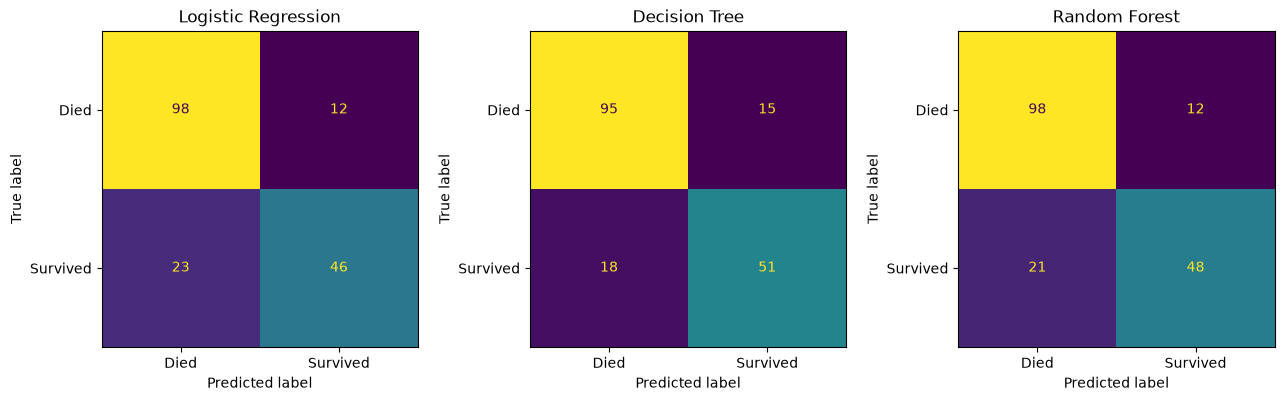

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, pipe) in zip(axes, fitted.items()):
    preds = pipe.predict(X_test)
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds),
                            display_labels=["Died", "Survived"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig("charts/08_confusion_matrices.png")
plt.show()

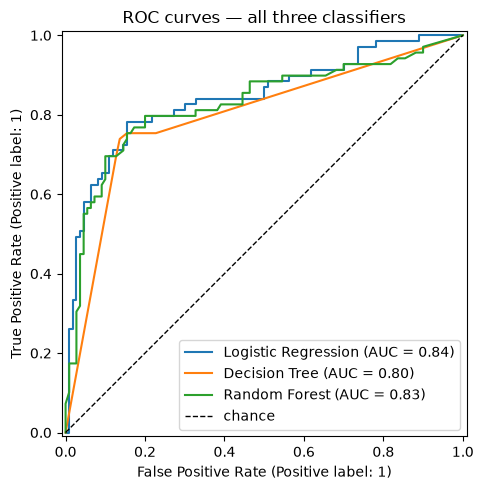

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, pipe in fitted.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="chance")
ax.set_title("ROC curves — all three classifiers")
ax.legend()
plt.tight_layout()
plt.savefig("charts/09_roc_curves.png")
plt.show()

## Decision Tree visualization
Rendered with `plot_tree`, using the one-hot-encoded feature names coming out of the `ColumnTransformer` and human readable class names.

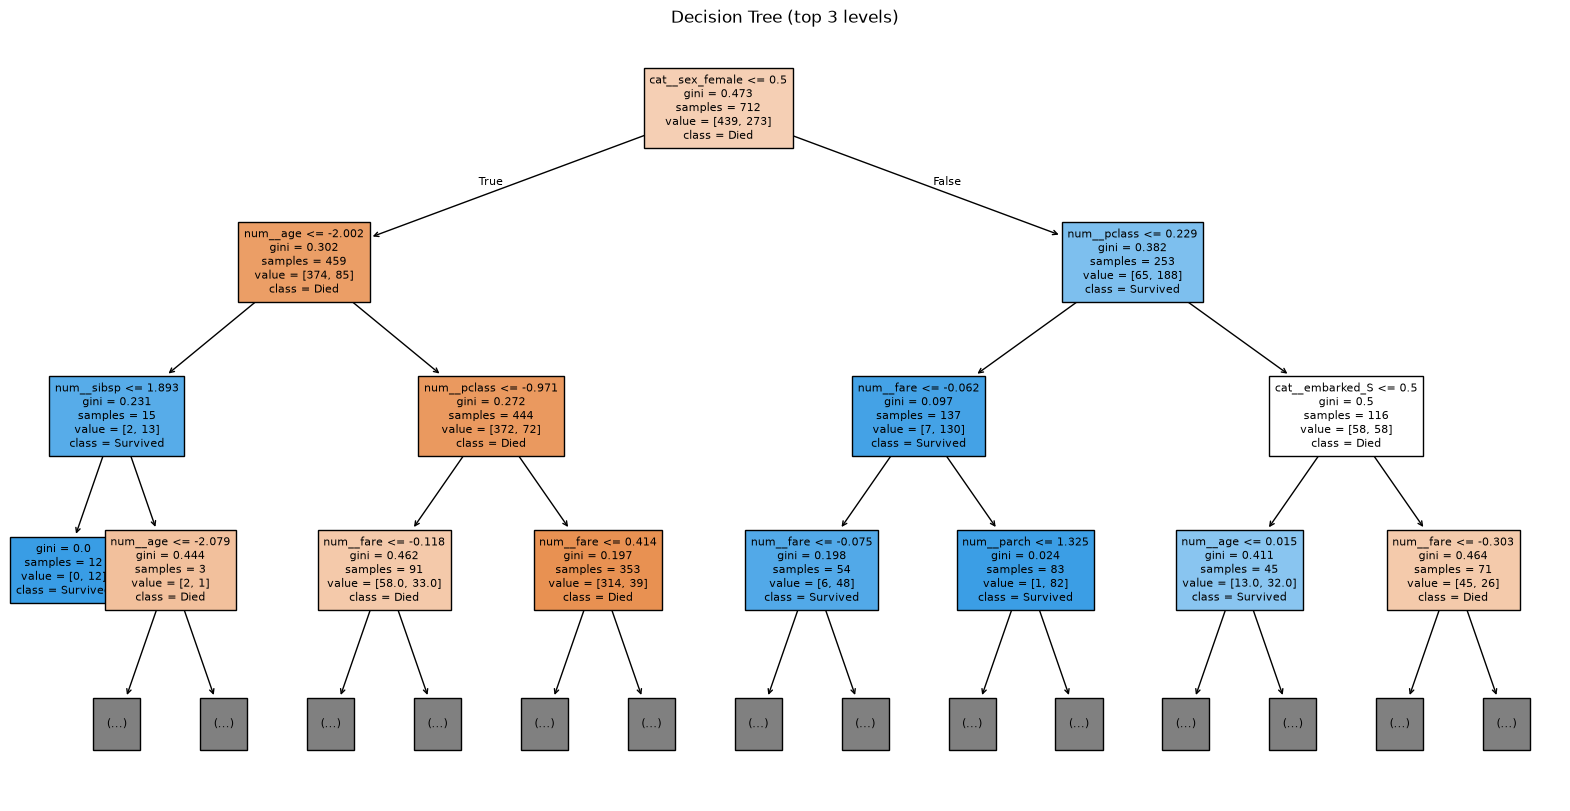

In [ ]:
feature_names = fitted["Decision Tree"].named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    fitted["Decision Tree"].named_steps["classifier"],
    feature_names=feature_names,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=3,       # top levels only, for readability
    fontsize=8,
)
plt.title("Decision Tree (top 3 levels)")
plt.savefig("charts/10_decision_tree.png", bbox_inches="tight")
plt.show()

## Task 9-Imbalance handling comparison (Logistic Regression)

Class balance (from the full training fold): 61.7% died / 38.3% survived- a moderate, not extreme, imbalance. We compare three strategies on the same model (Logistic Regression) and the same train/test split

In [ ]:
print("Training-fold class balance:")
print(y_train.value_counts(normalize=True).round(4))

# (a) baseline
base_pipe = Pipeline([("preprocessor", preprocessor),
                       ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
base_pipe.fit(X_train, y_train)
base_preds = base_pipe.predict(X_test)

# (b) class_weight='balanced'
bal_pipe = Pipeline([("preprocessor", preprocessor),
                      ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                                          class_weight="balanced"))])
bal_pipe.fit(X_train, y_train)
bal_preds = bal_pipe.predict(X_test)

# (c) SMOTE — fit preprocessor on train, resample the TRAINING fold only, then fit a plain classifier
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
X_train_sm, y_train_sm = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train_proc, y_train)
smote_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
smote_clf.fit(X_train_sm, y_train_sm)
smote_preds = smote_clf.predict(X_test_proc)

imbalance_df = pd.DataFrame({
    "baseline (no handling)": [precision_score(y_test, base_preds), recall_score(y_test, base_preds), f1_score(y_test, base_preds)],
    "class_weight='balanced'": [precision_score(y_test, bal_preds), recall_score(y_test, bal_preds), f1_score(y_test, bal_preds)],
    "SMOTE (train-fold only)": [precision_score(y_test, smote_preds), recall_score(y_test, smote_preds), f1_score(y_test, smote_preds)],
}, index=["precision", "recall", "f1"]).round(4)
imbalance_df

Training-fold class balance:
survived
0    0.6166
1    0.3834
Name: proportion, dtype: float64


,baseline (no handling),class_weight='balanced',SMOTE (train-fold only)
precision,0.7931,0.7297,0.7397
recall,0.6667,0.7826,0.7826
f1,0.7244,0.7552,0.7606


Conclusion: the baseline model favors precision (0.793) over recall (0.667) as it under predicts the minority "survived" class. Both class_weight='balanced' and SMOTE trade a bit of precision for a clear recall gain (0.667 → 0.783 in both cases), and both land on a higher F1 than the baseline. SMOTE edges out class_weight slightly on F1 (0.761 vs. 0.755) in this run, because generating synthetic minority examples gives the model more varied minority class training signal than reweighting the same examples more heavily, but the gap is small, and class_weight='balanced' is a reasonable, cheaper alternative since it needs no resampling step. Given this dataset's only moderate imbalance (62/38), both methods are reasonable choices compared with doing nothing.

## Task 10-Hyperparameter tuning: GridSearchCV on Random Forest (+OOB score)

oob_score=True is passed at construction time so oob_score_ is populated on the fitted estimator.

In [ ]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(oob_score=True, bootstrap=True, random_state=RANDOM_STATE)),
])

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"],
}

grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("Best params:", grid.best_params_)
print("OOB score of best estimator:", round(best_rf.named_steps["classifier"].oob_score_, 4))

rf_preds = best_rf.predict(X_test)
rf_proba = best_rf.predict_proba(X_test)[:, 1]
metrics["Random Forest (tuned)"] = {
    "accuracy": accuracy_score(y_test, rf_preds),
    "precision": precision_score(y_test, rf_preds),
    "recall": recall_score(y_test, rf_preds),
    "f1": f1_score(y_test, rf_preds),
    "auc": roc_auc_score(y_test, rf_proba),
}
pd.DataFrame(metrics).T.round(4)

Best params: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 300}
OOB score of best estimator: 0.823


,accuracy,precision,recall,f1,auc
Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437
Decision Tree,0.8156,0.7727,0.7391,0.7556,0.7967
Random Forest,0.8156,0.8000,0.6957,0.7442,0.8269
Random Forest (tuned),0.8156,0.8214,0.6667,0.7360,0.8391


## Task 11-Regression side-task: predict fare

Multivariate linear regression predicting fare from pclass, age, sibsp, parch, survived, sex, embarked using the same fit-on-train-only ColumnTransformer pattern.

In [ ]:
REG_NUM = ["pclass", "age", "sibsp", "parch", "survived"]
REG_CAT = ["sex", "embarked"]

Xr = df[REG_NUM + REG_CAT]
yr = df["fare"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=RANDOM_STATE)

reg_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), REG_NUM),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))]), REG_CAT),
])

reg_pipe = Pipeline([("preprocessor", reg_preprocessor), ("regressor", LinearRegression())])
reg_pipe.fit(Xr_train, yr_train)
yr_pred = reg_pipe.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
rmse = mean_squared_error(yr_test, yr_pred) ** 0.5
r2 = r2_score(yr_test, yr_pred)
n, p = Xr_test.shape[0], Xr_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

regression_metrics = {"MAE": mae, "RMSE": rmse, "R2": r2, "Adjusted R2": adj_r2}
pd.Series(regression_metrics).round(4)

MAE            20.8977
RMSE           30.5328
R2              0.3975
Adjusted R2     0.3729
dtype: float64

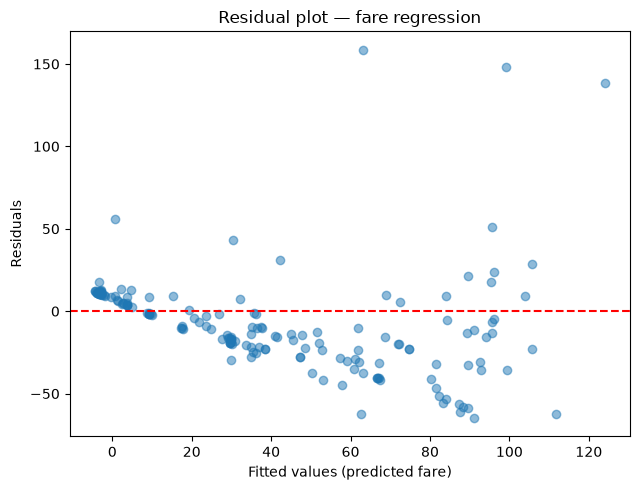

In [ ]:
residuals = yr_test - yr_pred

plt.figure(figsize=(6.5, 5))
plt.scatter(yr_pred, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values (predicted fare)")
plt.ylabel("Residuals")
plt.title("Residual plot — fare regression")
plt.tight_layout()
plt.savefig("charts/11_residual_plot.png")
plt.show()

Heteroscedasticity conclusion: The residual plot shows a clear funnel/cone shape, with residuals spreading wider as predicted fare increases, indicating heteroscedasticity. This is expected because fare is heavily right-skewed, and Ordinary least squares produces larger errors at the higher end due to a few very high-fare outliers.

## Task 12-Final model comparison and recommendation

Classification and regression metrics are on different scales (probabilities/rates vs. currency units) and are not directly comparable presented here as two separate metric groups, one per model type, not a single merged scale.

In [ ]:
classification_table = pd.DataFrame(metrics).T.round(4)
print("Classification models:")
display(classification_table)

regression_table = pd.Series(regression_metrics, name="Linear Regression (predicting fare)").round(4).to_frame().T
print("\nRegression model:")
display(regression_table)

Classification models:


,accuracy,precision,recall,f1,auc
Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437
Decision Tree,0.8156,0.7727,0.7391,0.7556,0.7967
Random Forest,0.8156,0.8000,0.6957,0.7442,0.8269
Random Forest (tuned),0.8156,0.8214,0.6667,0.7360,0.8391



Regression model:


,MAE,RMSE,R2,Adjusted R2
Linear Regression (predicting fare),20.8977,30.5328,0.3975,0.3729


Deploy the tuned Random Forest (n_estimators=300, max_depth=10, max_features='sqrt'). It has the highest testset precision (0.821) and accuracy (0.816), with an OOB score (0.823) close to its test accuracy, suggesting good generalization, while its AUC (0.839) is close to Logistic Regression's best AUC (0.844) and can capture the non-linear pclass × sex interaction. Logistic Regression is still a reasonable fallback when interpretability is more important than the small accuracy gain. The linear regression side task (R²=0.398) explains only about 40% of fare variance, so it is not considered a deployment candidate.

## Task 13 Save the complete fitted pipeline

We save the tuned Random Forest pipeline preprocessing (ColumnTransformer) and final estimator together as one object so it can be applied end-to-end to raw, unpreprocessed new data.

In [ ]:
joblib.dump(best_rf, "titanic_pipeline.joblib")
print("Saved full pipeline to titanic_pipeline.joblib")

reloaded = joblib.load("titanic_pipeline.joblib")

raw_new_passengers = pd.DataFrame([
    {"age": 4, "fare": 81.86, "sibsp": 1, "parch": 1, "pclass": 1, "sex": "female", "embarked": "S"},
    {"age": 29, "fare": 7.90, "sibsp": 0, "parch": 0, "pclass": 3, "sex": "male", "embarked": "Q"},
])
predictions = reloaded.predict(raw_new_passengers)
probabilities = reloaded.predict_proba(raw_new_passengers)[:, 1]
for i, (pred, proba) in enumerate(zip(predictions, probabilities)):
    label = "Survived" if pred == 1 else "Did not survive"
    print(f"Passenger {i}: prediction={label}  (P(survive)={proba:.3f})")

Saved full pipeline to titanic_pipeline.joblib


Passenger 0: prediction=Survived  (P(survive)=0.976)
Passenger 1: prediction=Did not survive  (P(survive)=0.317)


Both example passengers get sensible predictions straight from raw feature values (no manual preprocessing) — a young 1st-class female (historically very likely to survive) and an adult 3rd-class male (historically very unlikely to survive) — confirming the reloaded pipeline is usable end-to-end on new, unprocessed data.

---
This completes the Module 2 analytics pipeline: EDA → cleaning → visual story → stratified split → leak-free preprocessing → 3 classifiers → imbalance handling → hyperparameter tuning → regression side-task → final comparison/recommendation → saved deployable pipeline.